# Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de dataset

In [2]:
df = pd.read_excel("datos/Taller_KYC.xlsx", sheet_name="Hoja 1")
df.head()

,nombres_cliente,tipo_identifacion,identificacion,nacionalidad,luga_residencia,estado_civil,nombres_conyuge,identificacion_conyuge,ocupacion,actividad_economica,ingreso,activos,pasivos,tipo_transaccion,valor,Fecha
0,DIEGO ROLANDO AYALA AYALA,CEDULA,0603386665,ECUATORIANA,RIOBAMBA,CASADO,LORENA PATRICIA ZAMBRANO ALLAUCA,603606096.0,INDEPENDENTE,NaN,NaN,NaN,NaN,COMPRAVENTA,8000,2025-08-01 00:00:00
1,JORGE LUIS AUSHAY TIUQUINGA,CEDULA,0604634485,ECUATORIANA,CHAMBO,CASADO,GLADYS MARLENE YUQUILEMA YUQUILEMA,603695503.0,INDEPENDENTE,NaN,400.0,40000.0,22000.0,COMPRAVENTA,11801,2025-08-04 00:00:00
2,CRISTIAN BLADIMIR VARGAS TOAPANTA,CEDULA,0504834156,ECUATORIANA,TOACAZO LATACUNGA,SOLTERO,NaN,NaN,INDEPENDENTE,NaN,500.0,0.0,5000.0,COMPRAVENTA,11000,2025-08-04 00:00:00
3,TANIA LIZETH CENTENO HUILCA,CEDULA,1726684291,ECUATORIANA,QUITO,DIVORCIADA,NaN,NaN,EMPLEADO PRIVADO,SOLCA QUITO,1500.0,21000.0,18000.0,COMPRAVENTA,10000,2025-08-06 00:00:00
4,MARIA BENEDICTA CHINLLI GUAYÑA,CEDULA,0601552052,ECUATORIANA,RIOBAMBA,DIVORCIADA,NaN,NaN,INDEPENDENTE,COMERCIO,400.0,1000.0,0.0,COMPRAVENTA,10000,2025-08-06 00:00:00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   nombres_cliente         208 non-null    object 
 1   tipo_identifacion       208 non-null    object 
 2   identificacion          208 non-null    object 
 3   nacionalidad            208 non-null    object 
 4   luga_residencia         208 non-null    object 
 5   estado_civil            185 non-null    object 
 6   nombres_conyuge         104 non-null    object 
 7   identificacion_conyuge  91 non-null     float64
 8   ocupacion               163 non-null    object 
 9   actividad_economica     132 non-null    object 
 10  ingreso                 175 non-null    float64
 11  activos                 158 non-null    float64
 12  pasivos                 150 non-null    float64
 13  tipo_transaccion        208 non-null    object 
 14  valor                   208 non-null    in

In [4]:
# 1. IDENTIFICACIONES — siempre string, nunca número
# (float64 porque tiene NaN; al convertir hay que manejar eso)
df['identificacion'] = df['identificacion'].astype(str).str.strip().str.zfill(10)

df['identificacion_conyuge'] = df['identificacion_conyuge'].apply(
    lambda x: str(int(x)).zfill(10) if pd.notna(x) else np.nan
)
# zfill(10) porque las cédulas ecuatorianas son 10 dígitos
# el int() primero elimina el .0 que deja el float64

# 2. FECHA — object a datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True, errors='coerce')
# dayfirst=True por formato ecuatoriano DD/MM/YYYY
# errors='coerce' convierte fechas inválidas a NaT en vez de romper

# 3. ESTADO CIVIL — estandarizar mayúsculas y espacios
df['estado_civil'] = df['estado_civil'].str.strip().str.upper()

# 4. NOMBRES — limpiar espacios y mayúsculas
df['nombres_cliente'] = df['nombres_cliente'].str.strip().str.upper().str.replace(r'[\t\n\r]', ' ', regex=True).str.replace(r'\s+', ' ', regex=True)
df['nombres_conyuge'] = df['nombres_conyuge'].str.strip().str.upper().str.replace(r'[\t\n\r]', ' ', regex=True).str.replace(r'\s+', ' ', regex=True)


# 6. VERIFICAR RESULTADO
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   nombres_cliente         208 non-null    object        
 1   tipo_identifacion       208 non-null    object        
 2   identificacion          208 non-null    object        
 3   nacionalidad            208 non-null    object        
 4   luga_residencia         208 non-null    object        
 5   estado_civil            185 non-null    object        
 6   nombres_conyuge         104 non-null    object        
 7   identificacion_conyuge  91 non-null     object        
 8   ocupacion               163 non-null    object        
 9   actividad_economica     132 non-null    object        
 10  ingreso                 175 non-null    float64       
 11  activos                 158 non-null    float64       
 12  pasivos                 150 non-null    float64   

nombres_cliente                   object
tipo_identifacion                 object
identificacion                    object
nacionalidad                      object
luga_residencia                   object
estado_civil                      object
nombres_conyuge                   object
identificacion_conyuge            object
ocupacion                         object
actividad_economica               object
ingreso                          float64
activos                          float64
pasivos                          float64
tipo_transaccion                  object
valor                              int64
Fecha                     datetime64[ns]
dtype: object

In [5]:
df.head()

,nombres_cliente,tipo_identifacion,identificacion,nacionalidad,luga_residencia,estado_civil,nombres_conyuge,identificacion_conyuge,ocupacion,actividad_economica,ingreso,activos,pasivos,tipo_transaccion,valor,Fecha
0,DIEGO ROLANDO AYALA AYALA,CEDULA,0603386665,ECUATORIANA,RIOBAMBA,CASADO,LORENA PATRICIA ZAMBRANO ALLAUCA,0603606096,INDEPENDENTE,NaN,NaN,NaN,NaN,COMPRAVENTA,8000,2025-08-01
1,JORGE LUIS AUSHAY TIUQUINGA,CEDULA,0604634485,ECUATORIANA,CHAMBO,CASADO,GLADYS MARLENE YUQUILEMA YUQUILEMA,0603695503,INDEPENDENTE,NaN,400.0,40000.0,22000.0,COMPRAVENTA,11801,2025-08-04
2,CRISTIAN BLADIMIR VARGAS TOAPANTA,CEDULA,0504834156,ECUATORIANA,TOACAZO LATACUNGA,SOLTERO,NaN,NaN,INDEPENDENTE,NaN,500.0,0.0,5000.0,COMPRAVENTA,11000,2025-08-04
3,TANIA LIZETH CENTENO HUILCA,CEDULA,1726684291,ECUATORIANA,QUITO,DIVORCIADA,NaN,NaN,EMPLEADO PRIVADO,SOLCA QUITO,1500.0,21000.0,18000.0,COMPRAVENTA,10000,2025-08-06
4,MARIA BENEDICTA CHINLLI GUAYÑA,CEDULA,0601552052,ECUATORIANA,RIOBAMBA,DIVORCIADA,NaN,NaN,INDEPENDENTE,COMERCIO,400.0,1000.0,0.0,COMPRAVENTA,10000,2025-08-06


In [6]:
# Revisar cada columna object
cols_excluir = ['nombres_cliente', 'nombres_conyuge', 'identificacion', 'identificacion_conyuge']

for col in df.select_dtypes(include='object').columns:
    if col not in cols_excluir:
        print(f"\n=== {col} ===")
        print(df[col].unique())


=== tipo_identifacion ===
['CEDULA' 'RUC']

=== nacionalidad ===
['ECUATORIANA' 'ESPAÑOLA']

=== luga_residencia ===
['RIOBAMBA' 'CHAMBO' 'TOACAZO LATACUNGA' 'QUITO' 'GUARANDA' 'CUENCA'
 'SAN LUIS' 'CACHA' 'SAN ANDRES' 'COLTA' 'AMBATO' 'QUINSALOMA' 'CAJABAMBA'
 'GUAYAQUIL' 'PUNIN' 'EEUU' 'ALAUSI' 'GUANO' 'ESPAÑA' 'LICTO' 'PUYO'
 'DURAN' 'CAÑAR' 'GUAMOTE' 'PENIPE' 'SAN MIGUEL DE BOLIVAR' 'SALCEDO'
 'CHUNCHI' 'ESTADOS UNIDOS']

=== estado_civil ===
['CASADO' 'SOLTERO' 'DIVORCIADA' 'VIUDA' 'DIVORCIADO' 'VIUDO' nan
 'SOLTERA' 'CASADA']

=== ocupacion ===
['INDEPENDENTE' 'EMPLEADO PRIVADO' 'EMPLEADO PUBLICO' 'JUBILADO' 'POLICIA'
 nan 'INDEPENDIENTE' 'AMA DE CASA' 'ESTUDIANTE' 'JUBLILACION' 'JUBILIDO'
 'AGENTE OFICIOSO']

=== actividad_economica ===
[nan 'SOLCA QUITO' 'COMERCIO' 'COMISIONISTA VEHICULOS' 'FFAA' 'CHOFER'
 'DOCENTE' 'TECNICO SOCIAL' 'CARPINTERIA' 'ASESOR VENTAS' 'AGRICULTOR'
 'COMPRA VENTA DE VEHICULOS' 'POLICIA' 'SERVICIOS PROFESIONALES'
 'GAD YANAYACU' 'AGRICULTURA' 'COMISIO

In [7]:
mapa_estado_civil = {
    'CASADA'    : 'CASADO',
    'SOLTERA'   : 'SOLTERO',
    'DIVORCIADA': 'DIVORCIADO',
    'VIUDA'     : 'VIUDO',
}
df['estado_civil'] = df['estado_civil'].replace(mapa_estado_civil)

In [8]:
mapa_ocupacion = {
    'INDEPENDENTE' : 'INDEPENDIENTE',
    'JUBLILACION'  : 'JUBILADO',
    'JUBILIDO'     : 'JUBILADO',
}
df['ocupacion'] = df['ocupacion'].replace(mapa_ocupacion)

In [9]:
mapa_lugar = {
    'EEUU'          : 'ESTADOS UNIDOS',
    'TOACAZO LATACUNGA' : 'LATACUNGA',
}
df['luga_residencia'] = df['luga_residencia'].replace(mapa_lugar)


In [10]:
for col in ['estado_civil', 'ocupacion', 'luga_residencia']:
    print(f"\n=== {col} ===")
    print(sorted(df[col].dropna().unique()))


=== estado_civil ===
['CASADO', 'DIVORCIADO', 'SOLTERO', 'VIUDO']

=== ocupacion ===
['AGENTE OFICIOSO', 'AMA DE CASA', 'EMPLEADO PRIVADO', 'EMPLEADO PUBLICO', 'ESTUDIANTE', 'INDEPENDIENTE', 'JUBILADO', 'POLICIA']

=== luga_residencia ===
['ALAUSI', 'AMBATO', 'CACHA', 'CAJABAMBA', 'CAÑAR', 'CHAMBO', 'CHUNCHI', 'COLTA', 'CUENCA', 'DURAN', 'ESPAÑA', 'ESTADOS UNIDOS', 'GUAMOTE', 'GUANO', 'GUARANDA', 'GUAYAQUIL', 'LATACUNGA', 'LICTO', 'PENIPE', 'PUNIN', 'PUYO', 'QUINSALOMA', 'QUITO', 'RIOBAMBA', 'SALCEDO', 'SAN ANDRES', 'SAN LUIS', 'SAN MIGUEL DE BOLIVAR']


In [11]:
nulos = df.isna().sum()
porcentaje_nulos = nulos/len(df) * 100
nulos, porcentaje_nulos

(nombres_cliente             0
 tipo_identifacion           0
 identificacion              0
 nacionalidad                0
 luga_residencia             0
 estado_civil               23
 nombres_conyuge           104
 identificacion_conyuge    117
 ocupacion                  45
 actividad_economica        76
 ingreso                    33
 activos                    50
 pasivos                    58
 tipo_transaccion            0
 valor                       0
 Fecha                       1
 dtype: int64,
 nombres_cliente            0.000000
 tipo_identifacion          0.000000
 identificacion             0.000000
 nacionalidad               0.000000
 luga_residencia            0.000000
 estado_civil              11.057692
 nombres_conyuge           50.000000
 identificacion_conyuge    56.250000
 ocupacion                 21.634615
 actividad_economica       36.538462
 ingreso                   15.865385
 activos                   24.038462
 pasivos                   27.884615
 tipo_tr

In [12]:
df = df.dropna(subset=['Fecha'])

In [13]:
df['ocupacion'] = df['ocupacion'].fillna('DESCONOCIDO')
df['actividad_economica'] = df['actividad_economica'].fillna('DESCONOCIDO')


In [14]:
df['estado_civil'] = df['estado_civil'].fillna(df['estado_civil'].mode()[0])

In [15]:
numericas = ['activos', 'pasivos', 'ingreso']
for col in numericas:
    df[col] = df[col].fillna(df[col].median())

In [17]:
nulos = df.isna().sum()
porcentaje_nulos = nulos/len(df) * 100
nulos, porcentaje_nulos

(nombres_cliente             0
 tipo_identifacion           0
 identificacion              0
 nacionalidad                0
 luga_residencia             0
 estado_civil                0
 nombres_conyuge           104
 identificacion_conyuge    117
 ocupacion                   0
 actividad_economica         0
 ingreso                     0
 activos                     0
 pasivos                     0
 tipo_transaccion            0
 valor                       0
 Fecha                       0
 dtype: int64,
 nombres_cliente            0.000000
 tipo_identifacion          0.000000
 identificacion             0.000000
 nacionalidad               0.000000
 luga_residencia            0.000000
 estado_civil               0.000000
 nombres_conyuge           50.241546
 identificacion_conyuge    56.521739
 ocupacion                  0.000000
 actividad_economica        0.000000
 ingreso                    0.000000
 activos                    0.000000
 pasivos                    0.000000
 tipo_tr

In [16]:
ocupaciones = df['ocupacion'].unique()

for ocupacion in ocupaciones:
    subset = df[df['ocupacion'] == ocupacion]
    print(f"\n=== {ocupacion} ===")
    print(subset['actividad_economica'].unique())


=== INDEPENDIENTE ===
['DESCONOCIDO' 'COMERCIO' 'COMISIONISTA VEHICULOS' 'CHOFER' 'AGRICULTOR'
 'COMPRA VENTA DE VEHICULOS' 'SERVICIOS PROFESIONALES' 'AGRICULTURA'
 'COMISIONISTA' 'VENTA DE MAQUILLAJE' 'VENTA ACCESORIO VEHICULOS'
 'CONFECCION ROPA DEPORTIVA' 'MECANICO' 'OPERARIO DE JOYERIA'
 'ARTICULOS DEL HOGAR' 'COMPRA VENTA ELECTRODOMESTICOS' 'COMERCIANTE'
 'SERVICIOS FINANCIEROS' 'ALMACEN MUSICAL' 'NEGOCIO PROPIO' 'ING. CIVIL'
 'ELABORACION DE PAN' 'TRAMITES LEGALES' 'ALBAÑIL' 'SERVICIO DE TAXIS'
 'COMERCIO DE JOYAS' 'ELABORACION DE BLOQUES' 'LIMPIEZA' 'AUTOMOTRIZ'
 'PROMOTOR DE EVENTOS']

=== EMPLEADO PRIVADO ===
['SOLCA QUITO' 'CARPINTERIA' 'ASESOR VENTAS' 'DESCONOCIDO'
 'DOCENTE INSTRUCTOR' 'TURISMO' 'UNIVERSIDAD UTE' 'INMOVILIARIA'
 'BROKER SEGUROS' 'COORDINADOR ACTIVIDADES UNIVERSITARIA'
 'ALMACENES HIDALGO' 'PANIFICADOR' 'BIENES RAICES' 'COMPAÑIA INMOBILIARIA'
 'NEGOCIO PROPIO']

=== EMPLEADO PUBLICO ===
['FFAA' 'DESCONOCIDO' 'DOCENTE' 'TECNICO SOCIAL' 'POLICIA' 'GAD YANAYAC

In [20]:
patrimonio_ocupacion = df.groupby('estado_civil')[['activos', 'pasivos', 'ingreso']].agg(['mean', 'median', 'count'])
patrimonio_ocupacion

activos                       pasivos                \
                       mean    median count          mean  median count   
estado_civil                                                              
CASADO         63128.346457   23000.0   127  12495.511811  1500.0   127   
DIVORCIADO     71987.500000   23000.0    16  13875.000000  1500.0    16   
SOLTERO        21391.525424   15000.0    59   6044.067797  1500.0    59   
VIUDO         110700.000000  130000.0     5   1200.000000  1500.0     5   

                  ingreso                
                     mean  median count  
estado_civil                             
CASADO        4280.598425   800.0   127  
DIVORCIADO    1723.000000  1500.0    16  
SOLTERO       6002.661017   750.0    59  
VIUDO         1880.000000   800.0     5

In [19]:
nulos_conyugue = df.groupby('estado_civil')[['nombres_conyuge', 'identificacion_conyuge']].agg([
    ('nulos', lambda x: x.isna().sum()),
    ('porcentaje', lambda x: (x.isna().sum()/len(x))*100)
])
nulos_conyugue

nombres_conyuge             identificacion_conyuge            
                       nulos  porcentaje                  nulos  porcentaje
estado_civil                                                               
CASADO                    30   23.622047                     43   33.858268
DIVORCIADO                16  100.000000                     16  100.000000
SOLTERO                   53   89.830508                     53   89.830508
VIUDO                      5  100.000000                      5  100.000000

In [18]:
# Ver todas las combinaciones estado_civil vs datos de cónyuge
resumen = df.groupby('estado_civil').agg(
    total=('identificacion', 'count'),
    con_nombre_conyuge=('nombres_conyuge', 'count'),
    con_id_conyuge=('identificacion_conyuge', 'count'),
    porcentaje_nulos_nom_conyuge =('identificacion_conyuge', lambda x: (x.isna().sum()/len(x)*100)),
    porcentaje_nulos_id_conyuge =('identificacion_conyuge', lambda x: (x.isna().sum())/len(x)*100)
).reset_index()

print(resumen)

  estado_civil  total  con_nombre_conyuge  con_id_conyuge  \
0       CASADO    127                  97              84   
1   DIVORCIADO     16                   0               0   
2      SOLTERO     59                   6               6   
3        VIUDO      5                   0               0   

   porcentaje_nulos_nom_conyuge  porcentaje_nulos_id_conyuge  
0                     33.858268                    33.858268  
1                    100.000000                   100.000000  
2                     89.830508                    89.830508  
3                    100.000000                   100.000000  


In [93]:
solteros_sospechosos = df[df['estado_civil'] == 'SOLTERO'][df['nombres_conyuge'].notna() & df['identificacion_conyuge'].notna()]
solteros_sospechosos

C:\Users\Andy Nevarez\AppData\Local\Temp\ipykernel_24740\3784684053.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  solteros_sospechosos = df[df['estado_civil'] == 'SOLTERO'][df['nombres_conyuge'].notna() & df['identificacion_conyuge'].notna()]


,nombres_cliente,tipo_identifacion,identificacion,nacionalidad,luga_residencia,estado_civil,nombres_conyuge,identificacion_conyuge,ocupacion,actividad_economica,ingreso,activos,pasivos,tipo_transaccion,valor,Fecha
184,VERA COELLO JAVIER HIPOLITO,CEDULA,1202699284,ECUATORIANA,QUITO,SOLTERO,DOLORES JEANETTE CALVACHI NOBOA,1707980361,INDEPENDIENTE,AUTOMOTRIZ,480.0,23000.0,0.0,COMPRAVENTA,10000,2025-10-03
187,PILOCO SUAZTEGUI TERESA MARIBEL,CEDULA,1308887114,ECUATORIANA,QUITO,SOLTERO,CHIRIBOGA FRANCO PEDRO LUIS,0926488263,INDEPENDIENTE,AUTOMOTRIZ,NaN,NaN,0.0,COMPRAVENTA,8000,2025-10-03
198,VINTIMILLA BARRES FRANKLIN EDUARDO,CEDULA,1720512167,ECUATORIANA,QUITO,SOLTERO,AGUILERA GRANDA YUDITH GERMANIA,1105913808,INDEPENDIENTE,AUTOMOTRIZ,698.0,52000.0,0.0,COMPRAVENTA,8500,2025-11-10
200,ALVAREZ ARELLANO LUIS RAMON,CEDULA,0400634291,ECUATORIANA,QUITO,SOLTERO,MOLINEROS RUIZ ELIANA BELEN,0924539448,INDEPENDIENTE,AUTOMOTRIZ,698.0,52000.0,0.0,COMPRAVENTA,8500,2025-11-25
201,JERWIN SALVADOR CEVALLOS VIQUE,CEDULA,0605238945,ECUATORIANA,QUITO,SOLTERO,MOLINEROS RUIZ ELIANA BELEN,0924539448,INDEPENDIENTE,AUTOMOTRIZ,698.0,52000.0,0.0,COMPRAVENTA,8500,2025-11-27
202,TECNOLOGIA TOTAL TECTOTAL,RUC,1791265416001,ECUATORIANA,QUITO,SOLTERO,RENDERIA TORRES OSCAR AGUSTO,1715714877,INDEPENDIENTE,AUTOMOTRIZ,750.0,7800.0,0.0,COMPRAVENTA,9800,2025-12-16


In [ ]:
# Solo numéricas
df_numericas = df[['ingreso', 'activos', 'pasivos', 'valor']].copy()

# Matriz de correlación
corr = df_numericas.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre variables financieras')
plt.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'corr'

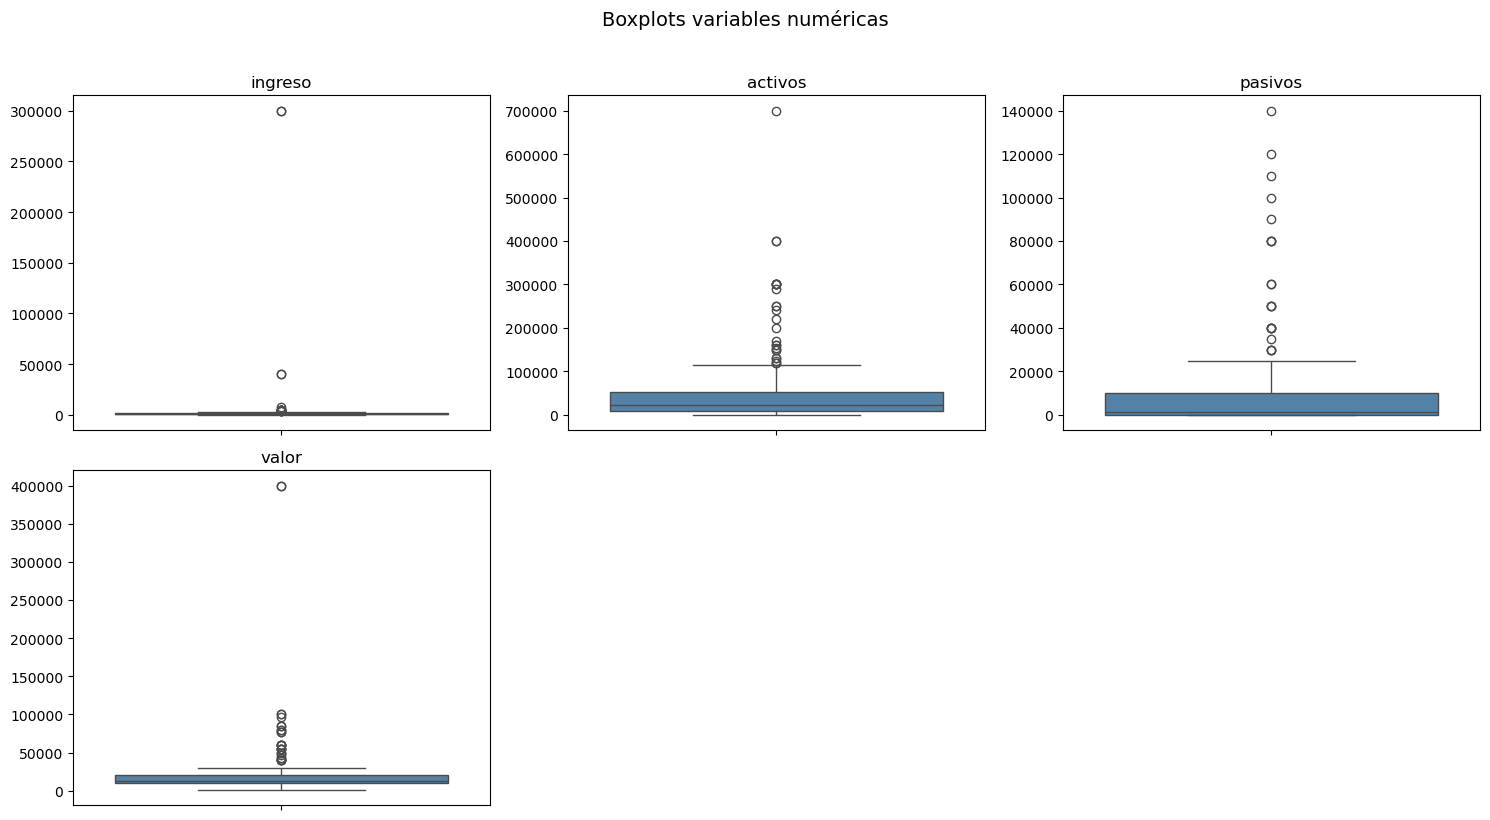

In [23]:
numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

# Ocultar subplots sobrantes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots variables numéricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()